# Vorlage Plausi-Tests

### Wohnbevölkerung der Stadt Zürich nach Alter und Postleitzahl, seit 1993

Wohnbevölkerung der Stadt Zürich nach Alter (5-Jahres-Altersklassen) und Postleitzahl. Es kann Postleitzahlen geben, die sowohl auf dem Gebiet der Stadt Zürich und auch ausserhalb umfassen. Im vorliegenden Datensatz ist aber nur die Wohnbevölkerung der Stadt Zürich vorhanden.


Datum: 15.03.2024

**Dataset auf INTEG Datenkatalog**:  https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_alter_plz_od5270

**Dataset auf PROD Datenkatalog**:  https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_alter_plz_od5270

`To Do (noch offen): PLZ-Geodaten mit den Werten in diesem Datensatz prüfen`

### Importiere die notwendigen Packages

In [39]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly

In [40]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns



In [41]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [42]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [43]:
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

Settings für Matplotlib

In [44]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

### Zeitvariabeln
Bestimme den aktuellst geladenen Monat. Hier ist es der Stand vor 2 Monaten. 
Bestimme noch weitere evt. sinnvolle Zeitvariabeln.

Zum Unterschied zwischen import datetime und from datedtime import datetime, siehe https://stackoverflow.com/questions/15707532/import-datetime-v-s-from-datetime-import-datetime

Zuerst die Zeitvariabeln als Strings

In [45]:
now = datetime.date.today()
date_today = now.strftime("%Y-%m-%d")
year_today = now.strftime("%Y")
month_today = now.strftime("%m")
day_today = now.strftime("%d")

date_day_a_week_ago = (datetime.datetime.now() - datetime.timedelta(days=7)).date()
day_a_week_ago = date_day_a_week_ago.strftime('%Y-%m-%d')


print(now," vor einer Woche: ", day_a_week_ago)


2024-03-10  vor einer Woche:  2024-03-03


#### Und hier noch die Zeitvariabeln als Integers:
- `aktuellesJahr`
- `aktuellerMonat`: Der gerade jetzt aktuelle Monat
- `selectedMonat`: Der aktuellste Monat in den Daten. In der Regel zwei Monate her.

In [46]:
#now = datetime.now() 
int_times = now.timetuple()

aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2

print(aktuellesJahr, 
      aktuellerMonat,
    'datenstand: ', selectedMonat,
     int_times)



2024 3 datenstand:  1 time.struct_time(tm_year=2024, tm_mon=3, tm_mday=10, tm_hour=0, tm_min=0, tm_sec=0, tm_wday=6, tm_yday=70, tm_isdst=-1)


### Setze einige Pfadvariabeln

- Der Packagename ist eigentlich der **Verzeichnisname** unter dem die Daten und Metadaten auf der Dropzone abgelegt werden.
- Definiert wird er bei SASA-Prozessen auf dem **Produkte-Sharepoint ([Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/PersonalViews.aspx?PageView=Personal&ShowWebPart={6087A3E7-8AC8-40BA-8278-DECFACE124FF}))**.
- Der Packagename wird auf CKAN teil der URL, daher ist die exakte Schreibweise wichtig.

Beachte: im Packagename müssen alle Buchstaben **klein** geschrieben werden. Dies weil CKAN aus grossen kleine Buchstaben macht.

##### `HIER ANPASSEN`

In [47]:
package_name = "bev_bestand_jahr_alter_plz_od5270"
dataset_name = "BEV527OD5270.csv"

**Statische Pfade in DWH-Dropzones und CKAN-URLs**

In [48]:
dropzone_path_integ = r"\\szh\ssz\applikationen\OGD_Dropzone\INT_DWH"
dropzone_path_prod = r"\\szh\ssz\applikationen\OGD_Dropzone\DWH"
ckan_integ_url ="https://data.integ.stadt-zuerich.ch/dataset/int_dwh_"
ckan_prod_url ="https://data.stadt-zuerich.ch/dataset/"

### Checke die Metadaten auf der CKAN INTEG- oder PROD-Webseite

Offenbar lassen sich aktuell im Markdownteil keine Variabeln ausführen, daher gehen wir wie unten gezeigt vor. Siehe dazu: https://data-dive.com/jupyterlab-markdown-cells-include-variables
Instead of setting the cell to Markdown, create Markdown from withnin a code cell! We can just use python variable replacement syntax to make the text dynamic

In [49]:
from IPython.display import Markdown as md

In [50]:
md(" **1. Dataset auf INTEG-Datakatalog:** Link {} ".format(ckan_integ_url+package_name))

 **1. Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_alter_plz_od5270 

In [51]:
md(" **2. Dataset auf PROD-Datakatalog:** Link {} ".format(ckan_prod_url+package_name))

 **2. Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_alter_plz_od5270 

### Importiere einen Datensatz 

Definiere zuerst folgende Werte:
1) Kommt der Datensatz von PROD oder INTEG?
2) Beziehst Du den Datensatz direkt ab der DROPZONE oder aus dem INTERNET?

In [52]:
#Die Datasets sind nur zum Testen auf INT-DWH-Dropzone. Wenn der Test vorbei ist, sind sie auf PROD. 
# Über den Status kann man einfach switchen

status = "integ"; #prod vs something else
data_source = "web"; #dropzone vs something else
print(status+" - "+ data_source)

integ - web


In [53]:
# Filepath
if status == "prod":
    if data_source == "dropzone":
            fp = dropzone_path_prod+"\\"+ package_name +"\\"+dataset_name
            print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_prod_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)
else:
    if data_source == "dropzone":
        fp = dropzone_path_integ+"\\"+ package_name +"\\"+dataset_name
        print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_integ_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)


fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_alter_plz_od5270/download/BEV527OD5270.csv


In [54]:
# Read the data
if data_source == "dropzone":
    data2betested = pd.read_csv(
        fp
        , sep=','
        ,parse_dates=['StichtagDatJahr']
        ,low_memory=False
    )
    print("dropzone")
else:
    r = requests.get(fp, verify=False)  
    r.encoding = 'utf-8'
    data2betested = pd.read_csv(
        io.StringIO(r.text)
        ,parse_dates=['StichtagDatJahr']
        # KONVERTIERE DAS SAS DATUM IN EIN UNIXDATUM UND FORMATIERE ES
        #, date_parser=lambda s: epoch + datetime.timedelta(days=int(s))
        ,low_memory=False)
    print("web")

data2betested.dtypes

web


StichtagDatJahr    datetime64[ns]
AlterV05Cd                  int64
AlterV05Lang               object
PLZ                         int64
AnzBestWir                  int64
dtype: object

Berechne weitere Attribute falls notwendig

In [55]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
        
    )
    .sort_values('Jahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr    datetime64[ns]
AlterV05Cd                  int64
AlterV05Lang               object
PLZ                         int64
AnzBestWir                  int64
Jahr               datetime64[ns]
Jahr_str                   object
Jahr_nbr                    int64
dtype: object

Minimales und maximales Jahr im Datensatz

In [56]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2023


### Einfache Datentests

In [57]:
data2betested.sort_values("AnzBestWir",ascending=True).head(2).T

,6881,6307
StichtagDatJahr,2005-01-01 00:00:00,2004-01-01 00:00:00
AlterV05Cd,50,45
AlterV05Lang,50- bis 54-Jährige,45- bis 49-Jährige
PLZ,8142,8152
AnzBestWir,1,1
Jahr,2005-01-01 00:00:00,2004-01-01 00:00:00
Jahr_str,2005-01-01,2004-01-01
Jahr_nbr,2005,2004


In [58]:
#data2betested.dtypes
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16809 entries, 16808 to 0
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   StichtagDatJahr  16809 non-null  datetime64[ns]
 1   AlterV05Cd       16809 non-null  int64         
 2   AlterV05Lang     16809 non-null  object        
 3   PLZ              16809 non-null  int64         
 4   AnzBestWir       16809 non-null  int64         
 5   Jahr             16809 non-null  datetime64[ns]
 6   Jahr_str         16809 non-null  object        
 7   Jahr_nbr         16809 non-null  int64         
dtypes: datetime64[ns](2), int64(4), object(2)
memory usage: 3.6 MB


In [59]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 16,809 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [60]:
data2betested = data2betested.set_index("Jahr")
data2betested = data2betested.sort_index()
#data2betested = data2betested.reset_index()

In [61]:
data2betested.index.year.unique()

Int64Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
            2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
            2021, 2022, 2023],
           dtype='int64', name='Jahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [62]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

,StichtagDatJahr,AlterV05Lang,Jahr_str
count,16809,16809,16809
unique,NaN,21,31
top,NaN,55- bis 59-Jährige,1995-01-01
freq,NaN,839,563
mean,2007-11-09 06:12:13.749776640,NaN,NaN
min,1993-01-01 00:00:00,NaN,NaN
25%,2000-01-01 00:00:00,NaN,NaN
50%,2008-01-01 00:00:00,NaN,NaN
75%,2016-01-01 00:00:00,NaN,NaN
max,2023-01-01 00:00:00,NaN,NaN


Beschreibe numerische Attribute

In [63]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,AlterV05Cd,PLZ,AnzBestWir,Jahr_nbr
count,"16,809","16,809","16,809","16,809"
mean,49,"8,077",718,"2,008"
std,30,273,654,9
min,0,"8,001",1,"1,993"
25%,25,"8,008",213,"2,000"
50%,50,"8,045",586,"2,008"
75%,75,"8,052","1,037","2,016"
max,100,"9,999","4,502","2,023"


#### Nullwerte und Missings?

Wie viele Nullwerte gibt es im Datensatz?

In [64]:
data2betested.isnull().sum()

StichtagDatJahr    0
AlterV05Cd         0
AlterV05Lang       0
PLZ                0
AnzBestWir         0
Jahr_str           0
Jahr_nbr           0
dtype: int64

### Gibt es Duplikate?

In [65]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,StichtagDatJahr,AlterV05Cd,AlterV05Lang,PLZ,AnzBestWir,Jahr_str,Jahr_nbr
Jahr,,,,,,,


In [66]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

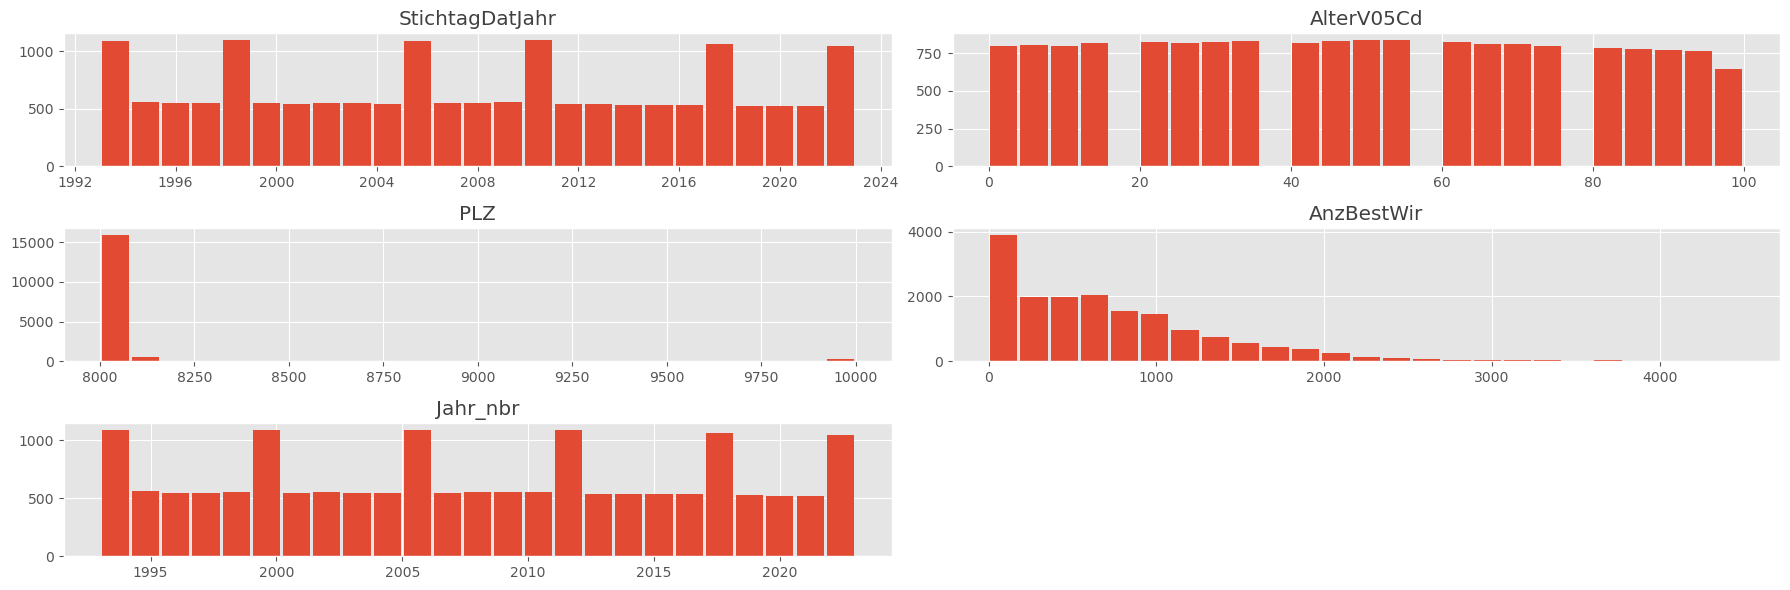

In [67]:
# plot a histogram for each numerical feature
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gruppierungen

In [68]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,sum_AnzBestWir
0,2023-01-01,447082
1,2022-01-01,443037
2,2021-01-01,436332


In [70]:
data2betested.columns

Index(['StichtagDatJahr', 'AlterV05Cd', 'AlterV05Lang', 'PLZ', 'AnzBestWir', 'Jahr_str',
       'Jahr_nbr'],
      dtype='object')

In [72]:
agg_PLZ = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['PLZ']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('PLZ', ascending=False) 
agg_PLZ.reset_index().head(4)

,PLZ,sum_AnzBestWir
0,9999,1863
1,8152,347
2,8143,151
3,8142,191


In [74]:
agg_Alter05 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterV05Cd', 'AlterV05Lang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AlterV05Cd', ascending=False) 
agg_Alter05.reset_index().head(4)

,AlterV05Cd,AlterV05Lang,sum_AnzBestWir
0,100,100-Jährige und Ältere,2461
1,95,95- bis 99-Jährige,22389
2,90,90- bis 94-Jährige,93007
3,85,85- bis 89-Jährige,209329


### Einfache Visualisierungen zur Plausi

Exploriere die Daten mit Pivottable.JS

In [ ]:
#pivot_ui(data2betested)

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [75]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,StichtagDatJahr,AlterV05Cd,AlterV05Lang,PLZ,AnzBestWir,Jahr_str,Jahr_nbr
Jahr,,,,,,,
2023-01-01,2023-01-01,0,0- bis 4-Jährige,8044,412,2023-01-01,2023
2023-01-01,2023-01-01,0,0- bis 4-Jährige,8041,716,2023-01-01,2023


### Visualisierungen nach Zeitausschnitten

#### Entwicklung der Wohnbevölkerung nach PLZ, seit 1993

In [76]:
data2betested.columns

Index(['StichtagDatJahr', 'AlterV05Cd', 'AlterV05Lang', 'PLZ', 'AnzBestWir', 'Jahr_str',
       'Jahr_nbr'],
      dtype='object')

In [79]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAggBar = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_str','PLZ']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('PLZ', ascending=True) 

myAggBar.reset_index().head(2)
#myAgg.reset_index().melt()

,Jahr,Jahr_str,PLZ,sum_AnzBestWir
0,1993-01-01,1993-01-01,8001,5589
1,1994-01-01,1994-01-01,8001,5426


In [81]:
myTitle="Entwicklung der Wohnbevölkerung nach PLZ, "+data_min_date + "- "+data_max_date

highlight = alt.selection(type='single', on='mouseover',
                          fields=['PLZ'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAggBar.reset_index().query('PLZ > 0'), title=myTitle).encode(
    x=alt.X('Jahr', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_AnzBestWir', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('PLZ', legend=alt.Legend(title="Kontinent", orient="right"))  
    ,tooltip=['Jahr', 'PLZ','sum_AnzBestWir']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=750 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(1.2), alt.value(4))
).interactive()

lines + points

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [92]:
myAggBar.reset_index().columns
myAggBar


,,,sum_AnzBestWir
Jahr,Jahr_str,PLZ,
1993-01-01,1993-01-01,8001,5589
1994-01-01,1994-01-01,8001,5426
2007-01-01,2007-01-01,8001,5026
2006-01-01,2006-01-01,8001,5060
2017-01-01,2017-01-01,8001,5747
...,...,...,...
2016-01-01,2016-01-01,9999,3
1999-01-01,1999-01-01,9999,126
2006-01-01,2006-01-01,9999,32


In [ ]:
#help(sns.catplot)  
#Stile for the following sns graphs
sns.set_theme(style="whitegrid")   

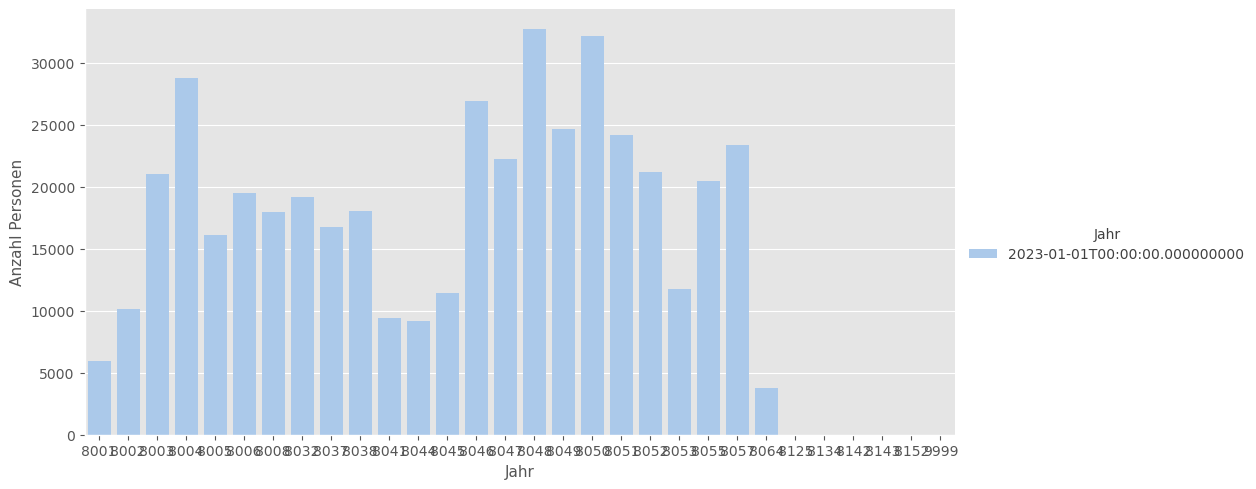

In [94]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="PLZ"
            , y="sum_AnzBestWir"
            , hue="Jahr"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBar.reset_index().query('Jahr =="2023-01-01"')
           )
myHist.set_xlabels('Jahr', fontsize=11) # not set_label
myHist.set_ylabels('Anzahl Personen', fontsize=11)


#### Facet Grids: Entwicklung der Bevölkerung nach PLZ, seit 1993

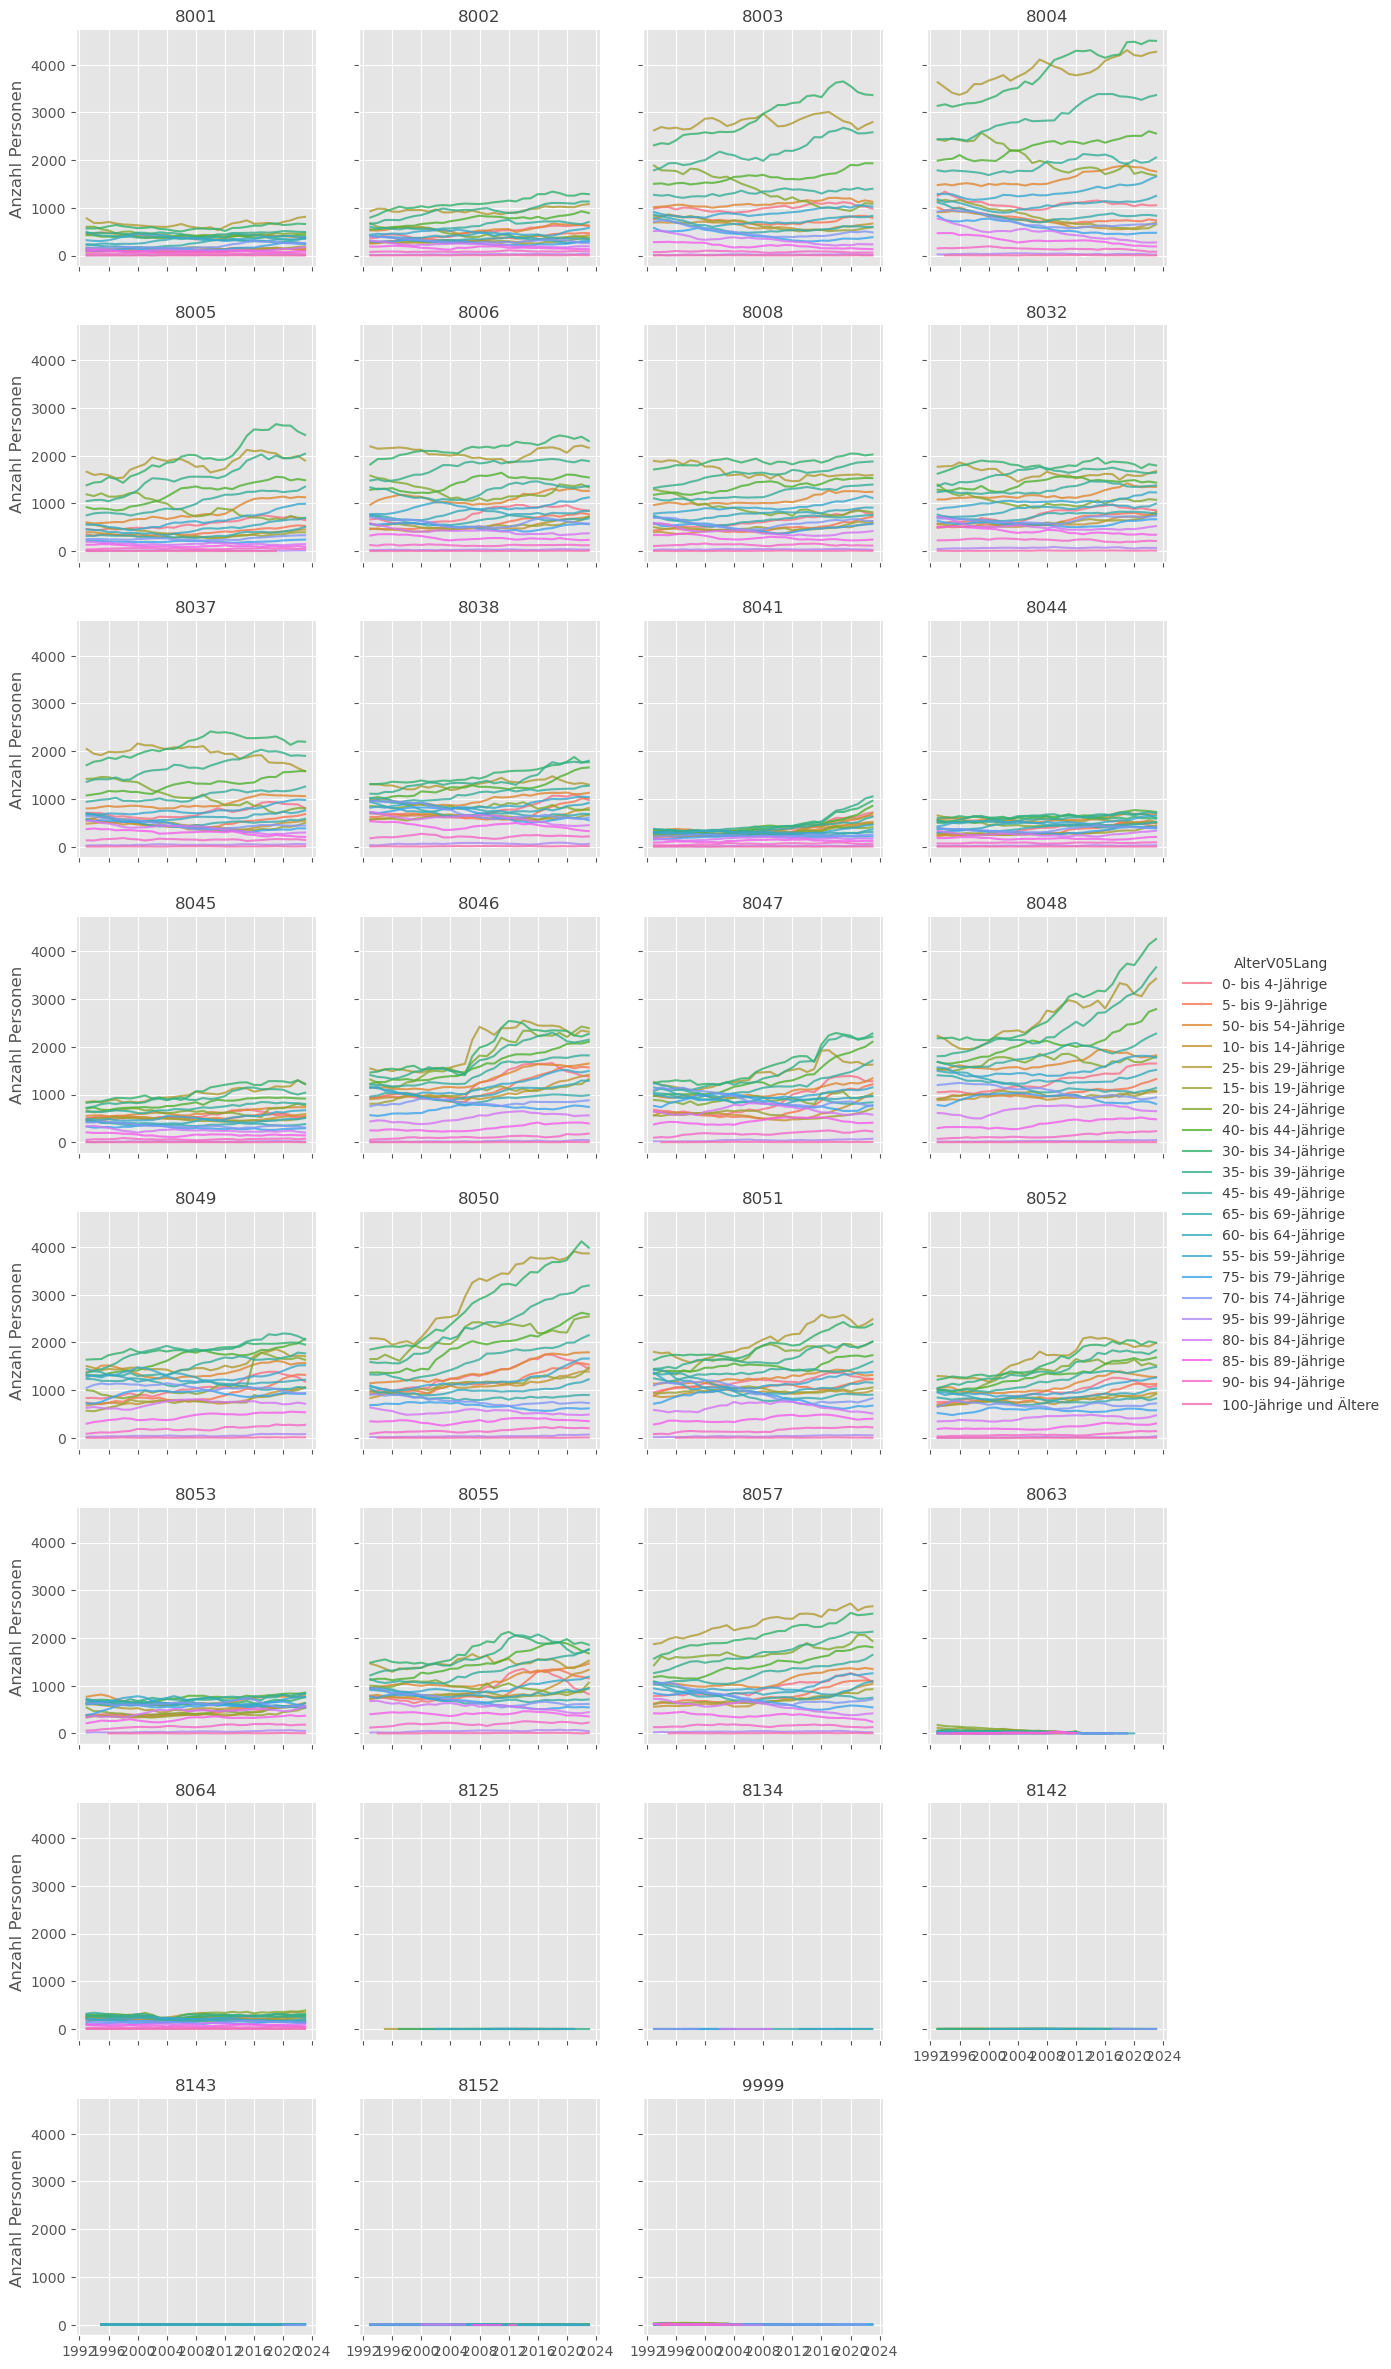

In [98]:
g2 = sns.FacetGrid(data2betested.reset_index(), col="PLZ", hue="AlterV05Lang", col_wrap=4, height=3,)
g2.map(sns.lineplot, "Jahr","AnzBestWir", alpha=.8)

g2.set_axis_labels("","Anzahl Personen")
g2.set_titles(col_template="{col_name}", row_template="{row_name}")
g2.add_legend()

In [95]:
data2betested.columns

Index(['StichtagDatJahr', 'AlterV05Cd', 'AlterV05Lang', 'PLZ', 'AnzBestWir', 'Jahr_str',
       'Jahr_nbr'],
      dtype='object')

### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

#### Wohnbevölkerung nach Staatsangehörigkeit, 2022

In [99]:
myTreemapAgg = data2betested.loc[data_max_date]\
    .groupby(['Jahr_nbr', 'AlterV05Cd', 'AlterV05Lang', 'PLZ']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('sum_AnzBestWir', ascending=False) 

#myTreemapAgg.reset_index()

Der Text beim hoovern ist per default zu lange, was es unübersichtlich macht. 
Was wie erscheinen soll ist im `hoovertemplate`erfasst. Ich lese es hier zuer aus und defniere es anschliessend neu.

In [103]:
myHeaderTitle="Wohnbevölkerung nach Altersgruppe und PLZ, "+data_max_date

fig = px.treemap(myTreemapAgg.reset_index(), path=[px.Constant(myHeaderTitle)
                ,'PLZ', 'AlterV05Lang']
                 , values='sum_AnzBestWir'
                 , color='AlterV05Lang'
                 ## bei discrete scales (bei Klassen und Strings):                 
                , color_discrete_map={'(?)':'lightgrey','Deutschland':'gold', 'Schweiz':'#FF3030', 'Türkei':'#EE3B3B', 'Serbien':'#A2CD5A','Kosovo':'#CAFF70','Österreich':'orange','Italien':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }             
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='cividis'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir'])  
                 ,height=500
                 ,width=1300                 
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))
#Was soll beim hoovern angezeigt werden?
fig.data[0].hovertemplate = '%{label}<br><br>AnzPers:<br>%{value}<extra></extra>'



fig.show()

In [106]:
myHeaderTitle="Wohnbevölkerung nach Altersgruppe und PLZ, "+data_max_date

fig = px.treemap(myTreemapAgg.reset_index(), path=[px.Constant(myHeaderTitle)
                ,'AlterV05Lang', 'PLZ']
                 , values='sum_AnzBestWir'
                 , color='AlterV05Lang'
                 ## bei discrete scales (bei Klassen und Strings):                 
                , color_discrete_map={'(?)':'lightgrey','Deutschland':'gold', 'Schweiz':'#FF3030', 'Türkei':'#EE3B3B', 'Serbien':'#A2CD5A','Kosovo':'#CAFF70','Österreich':'orange','Italien':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }             
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='cividis'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir'])  
                 ,height=500
                 ,width=1300                 
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))
#Was soll beim hoovern angezeigt werden?
fig.data[0].hovertemplate = '%{label}<br><br>AnzPers:<br>%{value}<extra></extra>'



fig.show()

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=151&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

## ---------------------- hier Plausi beendet

Liniendiagramm 
[Link zur Doku](https://altair-viz.github.io/gallery/multiline_highlight.html)

### Test: Choroplethenkarte
Importiere die Geodaten als GeoJSON

#### Stadtkreise

In [ ]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
geojson_url_kreise = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Stadtkreise?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_stadtkreise_v"
adm_stadtkreise_v = gpd.read_file(geojson_url_kreise)

adm_stadtkreise_v.head(1)


,id,kname,knr,objid,geometry
0,adm_stadtkreise_v.1,Kreis 6,6,1,"POLYGON ((8.52602 47.40844, 8.52625 47.40855, ..."


#### Statistische Zonen

In [ ]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
geojson_url_statzonen = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Zonen?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statzonen_map"
adm_statzonen_map = gpd.read_file(geojson_url_statzonen)

adm_statzonen_map.head(2)


,id,kname,knr,objectid,objid,qname,qnr,stzname,stznr,geometry
0,adm_statzonen_map.1,Kreis 7,7,1,154,Hirslanden,73,Hegibach,7303,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statzonen_map.2,Kreis 7,7,2,89,Hirslanden,73,Klus,7302,"POLYGON ((8.57281 47.35806, 8.57278 47.35807, ..."


#### Statistische Quartiere

In [ ]:
geojson_url_quartiere = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_map"
df_adm_statistische_quartiere_map = gpd.read_file(geojson_url_quartiere)

df_adm_statistische_quartiere_map.head(2)


,id,kname,knr,objectid,objid,qname,qnr,geometry
0,adm_statistische_quartiere_map.1,Kreis 7,7,1,34,Hirslanden,73,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statistische_quartiere_map.2,Kreis 8,8,2,33,Weinegg,83,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ..."


### Joins
Joine die importierten statistischen Daten des aktuellen Jahres zum Geodatensatz:

*Siehe dazu Doku zu [Geopandas](https://geopandas.org/docs/user_guide/mergingdata.html)*

In [ ]:
data2betested.dtypes

StichtagDatJahr    datetime64[ns]
QuarSort                    int64
QuarCd                      int64
QuarLang                   object
NationHistSort              int64
NationHistLang             object
NationSort                  int64
NationLang                 object
RegionSort                  int64
RegionLang                 object
KontinentSort               int64
KontinentLang              object
AnzBestWir                  int64
Jahr_str                   object
Jahr_nbr                    int64
dtype: object

In [ ]:
myAgg = data2betested.loc["2021"]  \
    .groupby(['QuarLang', 'QuarCd']) \
    .agg(sum_Whg_abgebrochen=('Whg_abgebrochen', 'sum'),sum_Whg_fertigerstellt=('Whg_fertigerstellt', 'sum')) \
    .sort_values('sum_Whg_abgebrochen', ascending=False) 

myAgg.reset_index().head(1)


KeyError: "Column(s) ['Whg_abgebrochen', 'Whg_fertigerstellt'] do not exist"

In [ ]:
# Rename attribute stznr to StatZoneSort, so the IDs have the same name
gdf_adm_statistische_quartiere_map = df_adm_statistische_quartiere_map[['geometry', 'qnr', 'qname', 'knr']].rename(columns={'qnr': 'QuarCd'})
gdf_adm_statistische_quartiere_map.head(1)

,geometry,QuarCd,qname,knr
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7


In [ ]:
# Merge with `merge` method on shared variable (stznr und StatZoneSort):
gdf_adm_statistische_quartiere_map_joined = gdf_adm_statistische_quartiere_map.merge(myAgg, on='QuarCd')
gdf_adm_statistische_quartiere_map_joined.head(2)


,geometry,QuarCd,qname,knr,sum_Whg_abgebrochen,sum_Whg_fertigerstellt
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7,48,2
1,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ...",83,Weinegg,8,2,0


<AxesSubplot:>

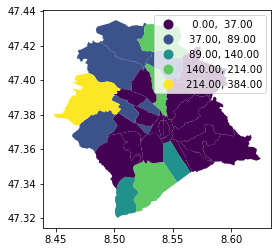

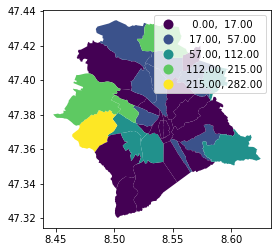

In [ ]:
# Plot by StatQuartiere
# Weitere Schemes: scheme='quantiles', scheme='fisherjenks', scheme='natural_breaks',

gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_fertigerstellt', cmap='viridis', scheme='natural_breaks', legend=True )
gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', cmap='viridis', scheme='natural_breaks', legend=True )

#gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', cmap='plasma', scheme='fisherjenks', legend=True )
#gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_fertigerstellt', cmap='cool', scheme='quantiles', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

#
#Neuere Gallerie: https://matplotlib.org/stable/gallery/index.html

<AxesSubplot:>

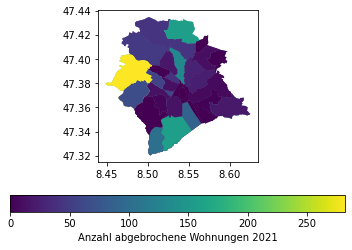

In [ ]:
fig, ax = plt.subplots(1, 1)

gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', ax=ax, legend=True, legend_kwds={'label': "Anzahl abgebrochene Wohnungen 2021",'orientation': "horizontal"})
gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_fertigerstellt', ax=ax, legend=False, legend_kwds={'label': "Anzahl fertigerstellte Wohnungen 2021",'orientation': "horizontal"})

#gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', cmap='viridis', scheme='natural_breaks', legend=True , ax=ax, legend_kwds={'label': "Anzahl Personen",'orientation': "horizontal"})

Noch zu prüfen, folgendes schöne Beispiel: https://docs.bokeh.org/en/latest/docs/user_guide/interaction/legends.html

Konkrete Beispiele von Bookeh in Jupyter NB: https://docs.bokeh.org/en/latest/docs/user_guide/jupyter.html